In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [3]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [4]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_1.txt', sep='\\s+')
df1

,time,v(vi),v(vo)
0,1.900000e-09,0.657403,0.633692
1,3.900000e-09,0.715501,0.692976
2,5.900000e-09,0.768872,0.748467
3,7.900000e-09,0.815328,0.797887
4,9.900000e-09,0.852969,0.839212
...,...,...,...
535,6.390000e-08,0.675281,0.897117
536,6.590000e-08,0.495724,0.300837
537,6.790000e-08,0.732193,0.897798
538,6.990000e-08,0.441234,0.305707


In [5]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [6]:
vi = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo = np.reshape(df1['v(vo)'].values, [runs, len(df1)//runs])

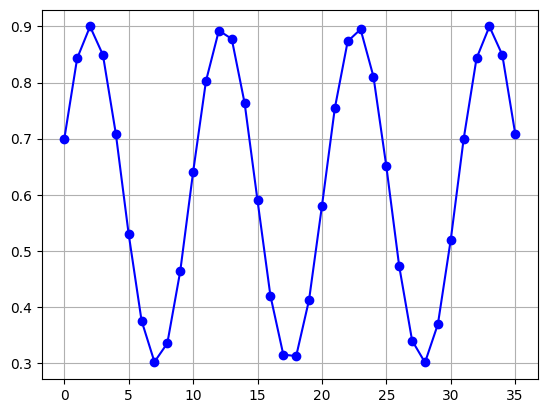

In [7]:
plt.plot(vo[2, :], "b-o")
plt.grid()
plt.show()

In [8]:
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

-1.1283801643799175e-08
1.3102013578392696e-07
1.1106215397495436e-07
1.0656696813853904e-08
-7.647830645756378e-07
-8.514703127537411e-07
1.8587577529233468e-07
4.887280861342956e-08
-2.4301354127428754e-06
-2.090577617996327e-06
4.483677492548214e-07
-5.85539677753141e-07
-1.6381428355405156e-07
-4.6985605150913544e-06
2.798515902657819e-06
3.2533338827529286e-06
-1.7590181749914682e-06
-5.358712152228765e-07
-1.2836589278184355e-06
-1.3006353020790795e-06
-3.710972698349718e-07
4.198703792144351e-06
4.173566731843387e-06
-7.4511280431629665e-06
-7.522378769765008e-07
1.4463356255592569e-06
-4.3631846032024436e-06
1.1601842030569334e-06
9.761673667625643e-06
-3.814012862710411e-05


In [14]:
# Analytical data
vov = 0.734
vm = 0.3
fs = 500e6
fin = bins*fs/ndft
c = 1.3e-12
cb = 400e-15
cp =  40e-15
fbw = 6.1e9
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cp/cb+0.2)**2)
print(fbw/1e6)

6100.0


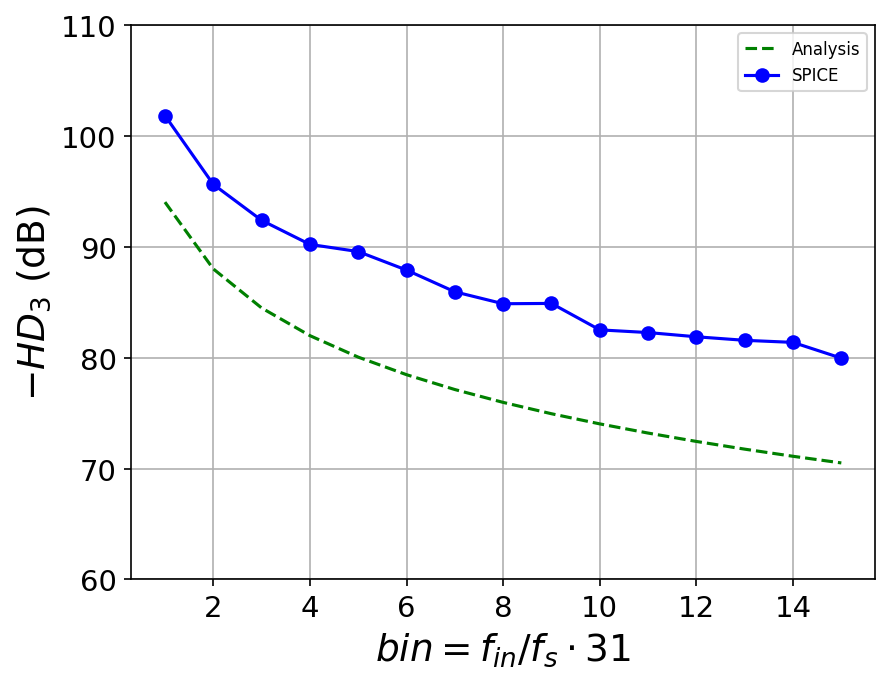

In [15]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_calc, "g--", label='Analysis')
#plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo, "b-o", label='SPICE')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(60, 110)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

3.2533338827529286e-06
-1.7590181749914682e-06
-5.358712152228765e-07
-1.2836589278184355e-06
-1.3006353020790795e-06
-3.710972698349718e-07
4.198703792144351e-06
4.173566731843387e-06
-7.4511280431629665e-06
-7.522378769765008e-07
1.4463356255592569e-06
-4.3631846032024436e-06
1.1601842030569334e-06
9.761673667625643e-06
-3.814012862710411e-05


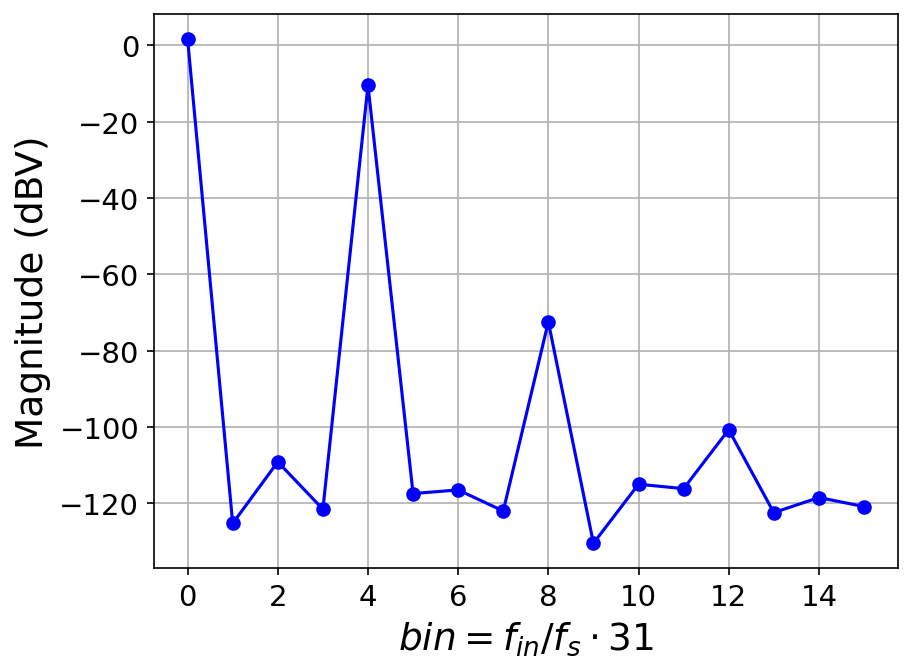

In [11]:
spec_dbv_out = compute_spectra(bins, vo, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o")
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.show()
